# Sentiment Analysis of Hotel Reviews using RNN, LSTM, and Word2Vec

This project focuses on classifying hotel reviews into positive and negative sentiments using deep learning models including Simple RNN, LSTM, and LSTM with pretrained Word2Vec embeddings.

In [13]:
!pip install numpy gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.2 MB/s eta 0:00:00


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [14]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [15]:
df = pd.read_csv("/content/drive/MyDrive/AI & ML/Hotel_Reviews.csv")

# Use review + label (adjust column names if needed)
df = df[['Review', 'Rating']]

# Convert rating to sentiment (binary)
df['sentiment'] = df['Rating'].apply(lambda x: 1 if x >= 3 else 0)

df.head()

,Review,Rating,sentiment
0,nice hotel expensive parking got good deal sta...,4,1
1,ok nothing special charge diamond member hilto...,2,0
2,nice rooms not 4* experience hotel monaco seat...,3,1
3,"unique, great stay, wonderful time hotel monac...",5,1
4,"great stay great stay, went seahawk game aweso...",5,1


# Text Preprocessing

Text preprocessing is performed to improve the quality of the textual data before training the models.

The preprocessing steps include:
- Lowercasing
- Removing URLs
- Removing hashtags and mentions
- Removing special characters
- Stopword removal
- Lemmatization

These steps help reduce noise and improve model performance.

In [16]:
import contractions

def clean_text(text):

    text = str(text).lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)

    # Remove numbers and special characters
    text = re.sub(r"[^a-z\s]", "", text)

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [w for w in words if w not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['cleaned'] = df['Review'].apply(clean_text)

df[['Review', 'cleaned']].head()

,Review,cleaned
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


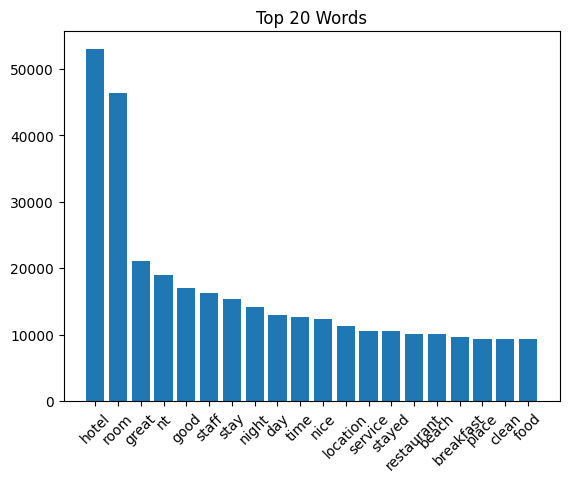

In [17]:
from collections import Counter

all_words = " ".join(df['cleaned']).split()
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)
words, counts = zip(*common_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.show()

In [22]:
X = df['cleaned']
y = df['sentiment']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Tokenizer
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [23]:
from tensorflow.keras.layers import Dropout

model_rnn = Sequential()

model_rnn.add(
    Embedding(
        input_dim=5000,
        output_dim=32,
        input_length=max_len
    )
)

model_rnn.add(SimpleRNN(32, dropout=0.2))

model_rnn.add(Dense(16, activation='relu'))

model_rnn.add(Dropout(0.3))

model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.8292 - loss: 0.4594 - val_accuracy: 0.8465 - val_loss: 0.4136
Epoch 2/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8454 - loss: 0.4074 - val_accuracy: 0.8475 - val_loss: 0.3923
Epoch 3/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.8608 - loss: 0.3582 - val_accuracy: 0.8478 - val_loss: 0.3983
Epoch 4/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.8698 - loss: 0.3049 - val_accuracy: 0.8673 - val_loss: 0.2990
Epoch 5/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8957 - loss: 0.2666 - val_accuracy: 0.8736 - val_loss: 0.3152
Epoch 6/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9099 - loss: 0.2374 - val_accuracy: 0.8741 - val_loss: 0.3132
Epoch 7/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.9189 - loss: 0.2167 - val_accuracy: 0.8644 - val_loss: 0.3520


In [24]:
model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=5000,
        output_dim=32,
        input_length=max_len
    )
)

model_lstm.add(
    LSTM(
        32,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

model_lstm.add(Dense(16, activation='relu'))

model_lstm.add(Dropout(0.3))

model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


513/513 ━━━━━━━━━━━━━━━━━━━━ 68s 115ms/step - accuracy: 0.8749 - loss: 0.3300 - val_accuracy: 0.9046 - val_loss: 0.2179
Epoch 2/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 60s 117ms/step - accuracy: 0.9238 - loss: 0.2046 - val_accuracy: 0.9139 - val_loss: 0.2208
Epoch 3/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 70s 136ms/step - accuracy: 0.9408 - loss: 0.1622 - val_accuracy: 0.9136 - val_loss: 0.2300
Epoch 4/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 70s 113ms/step - accuracy: 0.9479 - loss: 0.1450 - val_accuracy: 0.9153 - val_loss: 0.2378


In [27]:
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')

word_index = tokenizer.word_index
embedding_dim = 50

embedding_matrix = np.zeros((5000, embedding_dim))

for word, i in word_index.items():
    if i < 5000 and word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

model_w2v = Sequential()
model_w2v.add(Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
))
model_w2v.add(LSTM(64))
model_w2v.add(Dense(1, activation='sigmoid'))

model_w2v.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    callbacks=[EarlyStopping(patience=2)]
)

[==================================================] 100.0% 66.0/66.0MB downloaded
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


513/513 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.8690 - loss: 0.3254 - val_accuracy: 0.8851 - val_loss: 0.2750
Epoch 2/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.8921 - loss: 0.2619 - val_accuracy: 0.8997 - val_loss: 0.2543
Epoch 3/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 44s 64ms/step - accuracy: 0.9044 - loss: 0.2370 - val_accuracy: 0.9056 - val_loss: 0.2277
Epoch 4/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.9150 - loss: 0.2131 - val_accuracy: 0.9112 - val_loss: 0.2175
Epoch 5/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9163 - loss: 0.2025 - val_accuracy: 0.9083 - val_loss: 0.2145


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

RNN
              precision    recall  f1-score   support

           0       0.58      0.46      0.51       625
           1       0.91      0.94      0.92      3474

    accuracy                           0.87      4099
   macro avg       0.74      0.70      0.72      4099
weighted avg       0.86      0.87      0.86      4099



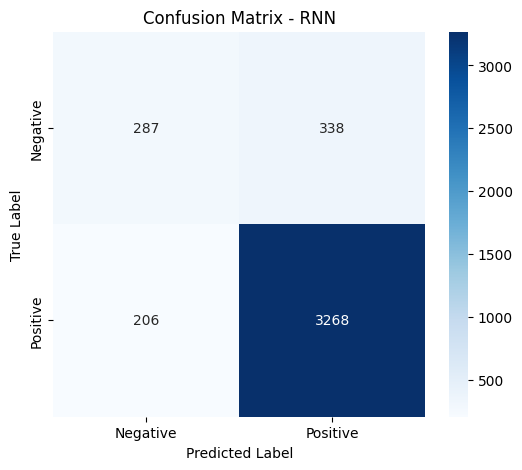

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

LSTM
              precision    recall  f1-score   support

           0       0.68      0.77      0.72       625
           1       0.96      0.93      0.95      3474

    accuracy                           0.91      4099
   macro avg       0.82      0.85      0.84      4099
weighted avg       0.92      0.91      0.91      4099



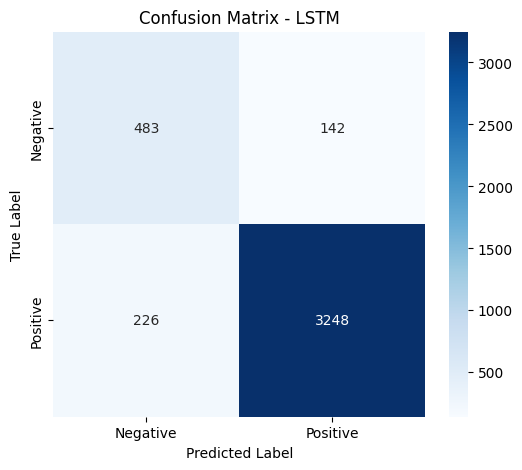

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step

Word2Vec LSTM
              precision    recall  f1-score   support

           0       0.70      0.71      0.70       625
           1       0.95      0.94      0.95      3474

    accuracy                           0.91      4099
   macro avg       0.82      0.83      0.82      4099
weighted avg       0.91      0.91      0.91      4099



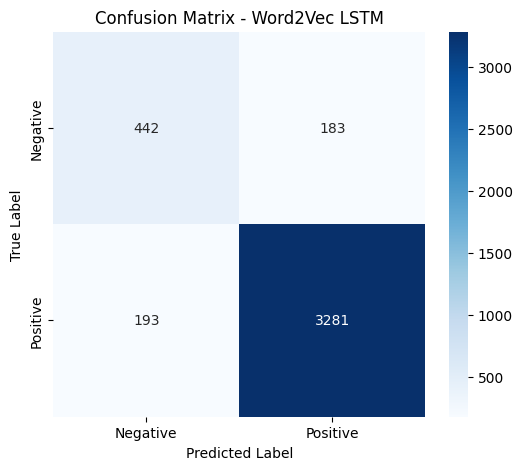

In [28]:
import seaborn as sns

def evaluate(model, X_test, y_test, model_name):

    preds = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n{model_name}")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive']
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")

    plt.show()

    return preds

preds_rnn = evaluate(model_rnn, X_test_pad, y_test, "RNN")
preds_lstm = evaluate(model_lstm, X_test_pad, y_test, "LSTM")
preds_w2v = evaluate(model_w2v, X_test_pad, y_test, "Word2Vec LSTM")

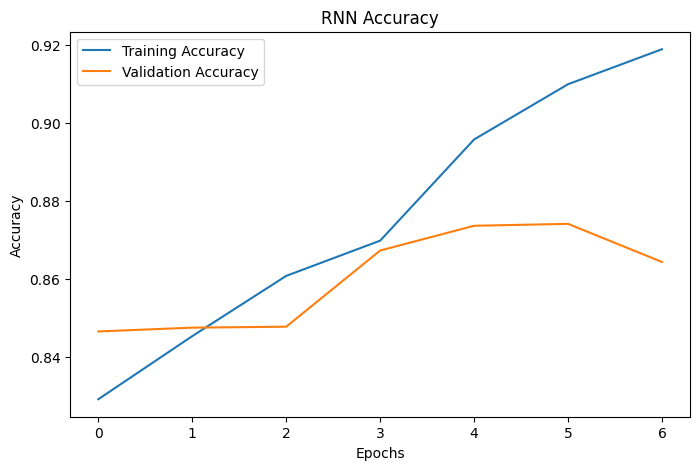

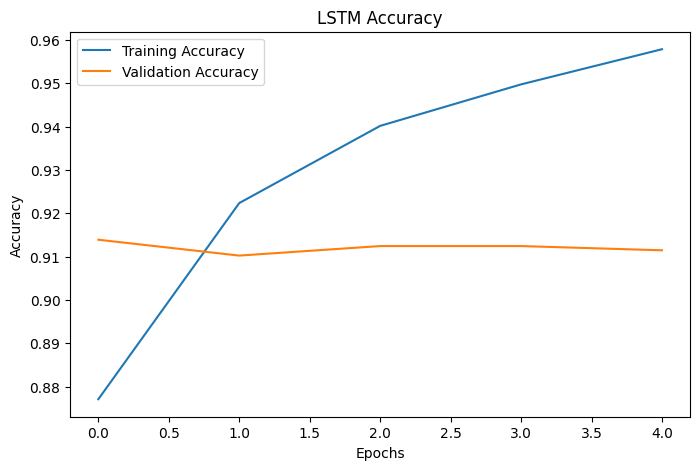

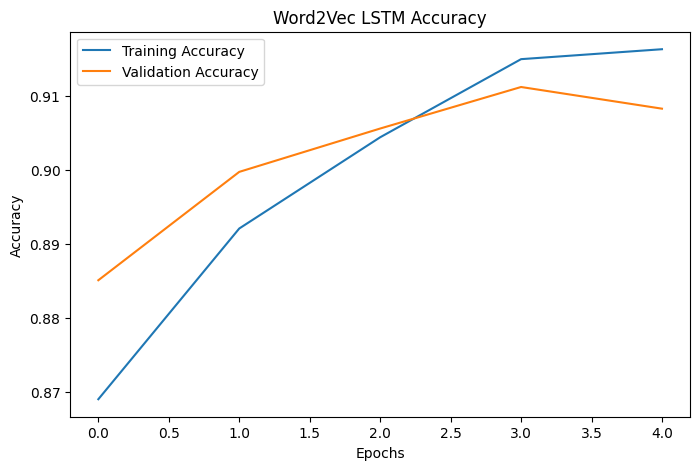

In [29]:
def plot_history(history, title):

    plt.figure(figsize=(8,5))

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{title} Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

plot_history(history_rnn, "RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_w2v, "Word2Vec LSTM")

In [30]:
count = 0

for i in range(len(X_test)):

    pred_label = preds_w2v[i][0]
    true_label = y_test.iloc[i]

    if pred_label != true_label:

        print("TEXT:")
        print(X_test.iloc[i])

        print("\nTRUE:", true_label)
        print("PREDICTED:", pred_label)

        print("-"*80)

        count += 1

        if count == 5:
            break

TEXT:
barcelona rock stayed hotel jazz girlfriend night end augustthe hotel excellent location carrer pelai close placa catalunya ramblas appreciate buzz city removed respite mayhem crowd caught airport bus barcelona cost euro person return trip hotel located min walk maximum placa universitat stop nd route hotel modern clean air conditioning room superb balcony looking street outside room good size bathroom fine scrimp bit toiletry bring shower gel unless consider washing unnecessary luxury travelsthe downside hotel possibly strength depending viewpoint hotel superbly situated different metro station extremely handy need city sight downside feel rumbling train hotel rd floor located worse incessant sound taxi horn hotel mela time square nyc ca nt say disturbed consideration light sleeper irritation couple shop hotel useful snack drink want avoid minibar price pool roof tiny nt recommend booking pretty nice place kill time particularly check day wanted sit chill nt expect able sit nigh

# GUI Implementation

A Gradio-based graphical user interface (GUI) is implemented to allow users to enter hotel reviews and receive real-time sentiment predictions from the trained LSTM model.

In [31]:
import gradio as gr

def predict_sentiment(text):

    cleaned = clean_text(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(seq, maxlen=max_len)

    pred = model_lstm.predict(padded)[0][0]

    if pred > 0.5:
        return "Positive Review"

    return "Negative Review"

interface = gr.Interface(
    fn=predict_sentiment,
    inputs="text",
    outputs="text",
    title="Hotel Review Sentiment Analysis"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://03b202a00177e3bc3c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
